# 🎓 Predicting 2025 Tuition Costs by State

**Primary Function**  
Predicts specific tuition-related values (e.g., **$8,503** for room/board), providing students with a concrete cost figure to guide their college decisions.

---

## 📈 Project Impact

- **Budgeting**  
  Establishes expense baselines.  
  _Example_: “$16,546/year — plan $1,379/month”

- **Goal Support**  
  Helps set and track realistic savings goals.  
  _Example_: “Save $4,000 for first-year tuition in 6 months”

- **Decision-Making**  
  Empowers smarter school selections based on affordability. 

- **User Benefit**  
  Answers the key question: _“How much will it cost?”_  


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Data Loading & Preprocessing
- Load cleaned dataset from CSV.
- Split into train (70%), validation (15%), and test (15%) sets.
- Scale features using StandardScaler.

In [2]:
# Load data
df = pd.read_csv('C:/Users/anand/OneDrive/Documents/MoneyLit/MoneyLit/Assets/Avg Cost by state/cleaned.csv')
X = df.drop('Value', axis=1).values
y = df['Value'].values

# Train-validation-test split (70-15-15)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1875, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create data loaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32)

## Model Architecture
- Input: 55 features.
- Layers: 64 (with BN, ReLU, Dropout) → 32 (with BN, ReLU, Dropout) → 1.
- Goal: Predict tuition cost (continuous value).

In [3]:
class StateCostMLP(nn.Module):
    def __init__(self, input_size=55):
        super(StateCostMLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        self.layer2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output(x)
        return x

model = StateCostMLP()

## Training
- Optimizer: Adam (lr=0.001) with scheduler.
- Loss: Mean Squared Error.
- Early stopping based on validation loss.

In [4]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

num_epochs = 500
train_losses = []
val_losses = []
patience = 20
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_statecost_mlp.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load('best_statecost_mlp.pth'))

Epoch [50/500], Train Loss: 114864895.0345, Val Loss: 109201424.0000
Epoch [100/500], Train Loss: 81823375.8621, Val Loss: 77689336.5714
Epoch [150/500], Train Loss: 48517284.4138, Val Loss: 46633227.0000
Epoch [200/500], Train Loss: 21579138.9914, Val Loss: 20657584.0000
Epoch [250/500], Train Loss: 9613648.4957, Val Loss: 5522044.1607
Epoch [300/500], Train Loss: 3814151.3664, Val Loss: 1398609.6652
Early stopping at epoch 328


<All keys matched successfully>

## Evaluation
- Metrics: MAE, MSE, R².
- Visualizations: Predicted vs Actual, Loss Curves.

Test MAE: $555.43
Test MSE: 758180.62
Test R²: 0.9678


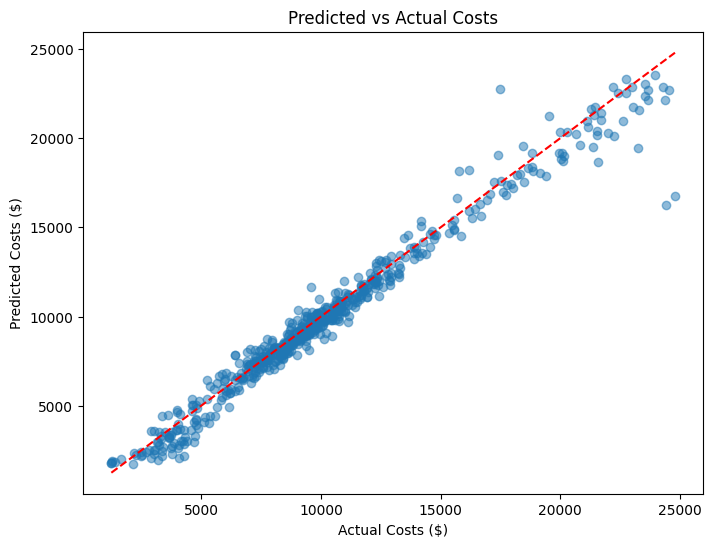

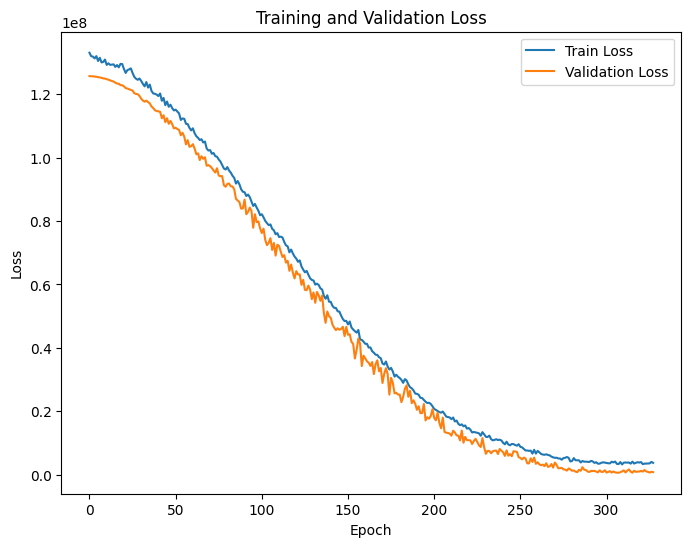

In [5]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    mae = torch.mean(torch.abs(y_pred - y_test)).item()
    mse = criterion(y_pred, y_test).item()
    r2 = r2_score(y_test.numpy(), y_pred.numpy())
    print(f'Test MAE: ${mae:.2f}')
    print(f'Test MSE: {mse:.2f}')
    print(f'Test R²: {r2:.4f}')

# Plot predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Costs ($)')
plt.ylabel('Predicted Costs ($)')
plt.title('Predicted vs Actual Costs')
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Inference
- Predict 2025 costs with 3% annual inflation.
- Example: Virginia, Public Out-of-State, 4-year.

In [6]:
# Custom prediction (Virginia, Public Out-of-State, 4-year)
custom_input = np.zeros(55)
custom_input[0] = 2021  # Year
custom_input[48] = 1    # state_Virginia
custom_input[53] = 1    # type_Public Out-of-State
custom_input[54] = 1    # length_4-year

custom_input_scaled = scaler.transform([custom_input])
custom_tensor = torch.tensor(custom_input_scaled, dtype=torch.float32)

inflation_factor = 1.03 ** 5  # 2020 to 2025
with torch.no_grad():
    pred = model(custom_tensor)
    pred_2025 = pred.item() * inflation_factor
    total_cost = pred_2025 + 14000  # Adding room/board
    print(f"Predicted 2025 Tuition (Virginia, Public Out-of-State, 4-year): ${pred_2025:.2f}")
    print(f"Total with $14K Room/Board: ${total_cost:.2f}")

Predicted 2025 Tuition (Virginia, Public Out-of-State, 4-year): $11187.72
Total with $14K Room/Board: $25187.72


## Interactive Predictions
- Use sliders to explore predictions for different inputs.